In [1]:
import os
import numpy as np
import pandas as pd
from sklearn import metrics
import matplotlib.pyplot as plt

In [2]:
start_year = 2004
end_year = start_year
pred_file = f'../results/{start_year}-{end_year}/hdpsm_nrep10_mratio5_drug_reaction_associations.csv'

In [3]:
preds = pd.read_csv(pred_file)
preds['reaction'] = preds['reaction'].str.lower()
preds['mean'] = preds['a']/(preds['a']+preds['b'])
preds['prr_diff'] = np.log(preds['PRR'])-np.log(preds['uncorrected_PRR'])
preds = preds[preds['sex']=='All']
preds = preds.dropna()
preds.head()

,drug,reaction,sex,replicate,a,b,c,d,OR,PRR,PHI,uncorrected_a,uncorrected_b,uncorrected_c,uncorrected_d,uncorrected_OR,uncorrected_PRR,uncorrected_PHI,mean,prr_diff
3,cabergoline,oedema peripheral,All,0,9,107,11,435,3.326253,3.145768,0.115617,13.0,142.0,3194.0,201714.0,5.781708,5.380661,0.015125,0.077586,-0.536753
5,cabergoline,condition aggravated,All,0,12,104,11,435,4.562937,4.194357,0.160946,13.0,142.0,3965.0,200943.0,4.639644,4.334384,0.012857,0.103448,-0.032839
6,cabergoline,cardiac failure,All,0,11,105,4,442,11.576190,10.573276,0.215597,14.0,141.0,1037.0,203871.0,19.520261,17.847463,0.032815,0.094828,-0.523532
7,cabergoline,mitral valve incompetence,All,0,10,106,5,441,8.320755,7.689655,0.188320,13.0,142.0,329.0,204579.0,56.927244,52.236572,0.055407,0.086207,-1.915907
8,cabergoline,hallucination,All,0,16,100,8,438,8.760000,7.689655,0.240192,19.0,136.0,975.0,203933.0,29.221169,25.761800,0.046622,0.137931,-1.209017


In [4]:
# positive controls
fn = '../data/onsides_public_warnings_and_precautions.csv'
positive_df = pd.read_csv(fn)
positive_df['pt_meddra_term'] = positive_df['pt_meddra_term'].str.lower()
positive_df.rename(columns={'pt_meddra_term': 'reaction', 'ingredients_names': 'drug'}, inplace=True)
positive_df['label'] = 1
positive_df.head()

,ingredients_rxcuis,drug,pt_meddra_id,reaction,label
0,321988,escitalopram,10012218,delirium,1
1,1364347,ponatinib,10003668,atrial tachycardia,1
2,4493,fluoxetine,10025197,lymphadenopathy,1
3,4099,"estrogens, conjugated (USP)",10016807,fluid retention,1
4,753340,sapropterin,10037211,psychomotor hyperactivity,1


In [5]:
merged = pd.merge(preds, positive_df, on=['drug', 'reaction'], how='left')
merged['label'] = merged['label'].fillna(0)
merged.head()

,drug,reaction,sex,replicate,a,b,c,d,OR,PRR,...,uncorrected_c,uncorrected_d,uncorrected_OR,uncorrected_PRR,uncorrected_PHI,mean,prr_diff,ingredients_rxcuis,pt_meddra_id,label
0,cabergoline,oedema peripheral,All,0,9,107,11,435,3.326253,3.145768,...,3194.0,201714.0,5.781708,5.380661,0.015125,0.077586,-0.536753,NaN,NaN,0.0
1,cabergoline,condition aggravated,All,0,12,104,11,435,4.562937,4.194357,...,3965.0,200943.0,4.639644,4.334384,0.012857,0.103448,-0.032839,NaN,NaN,0.0
2,cabergoline,cardiac failure,All,0,11,105,4,442,11.576190,10.573276,...,1037.0,203871.0,19.520261,17.847463,0.032815,0.094828,-0.523532,NaN,NaN,0.0
3,cabergoline,mitral valve incompetence,All,0,10,106,5,441,8.320755,7.689655,...,329.0,204579.0,56.927244,52.236572,0.055407,0.086207,-1.915907,NaN,NaN,0.0
4,cabergoline,hallucination,All,0,16,100,8,438,8.760000,7.689655,...,975.0,203933.0,29.221169,25.761800,0.046622,0.137931,-1.209017,NaN,NaN,0.0


0.6519754265493235
0.13869221662042938


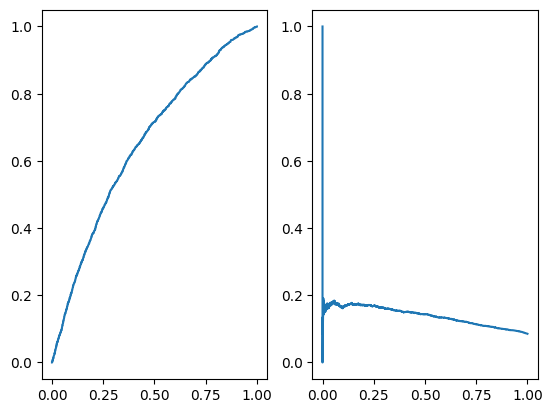

In [9]:
col = 'mean'

print(metrics.roc_auc_score(merged['label'], merged[col]))
print(metrics.average_precision_score(merged['label'], merged[col]))
fpr, tpr, thresholds = metrics.roc_curve(merged['label'], merged[col], pos_label=1)
plt.subplot(1,2,1)
plt.plot(fpr, tpr)

pr, re, th = metrics.precision_recall_curve(merged['label'], merged[col])
plt.subplot(1,2,2)
plt.plot(re, pr)


In [10]:
neg = merged[col][merged['label']==0]
pos = merged[col][merged['label']==1]
neg.mean(), pos.mean()

(0.02315201694081698, 0.03615143653605077)